In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm.notebook import tqdm

os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
from keras import layers
from keras import ops


2025-01-13 15:03:31.483073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Prepare the data

In [3]:
game_folder = "data/game_data.csv"
time_folder = "data/time_data.csv"

game_data = pd.read_csv(game_folder)
time_data = pd.read_csv(time_folder)

In [4]:
time_data.sample(5)

,user_id,game_id,playtime
327578,506,12012,690
14378,15,3620,1048
1348094,4462,27031,1
1590807,5978,4445,23
1654824,6279,6182,80


In [5]:
# make the playtime in hours, remove games with less than 1 hour of playtime
time_data['playtime'] = time_data['playtime'] // 60
time_data = time_data[time_data['playtime'] != 0]
time_data.head()

,user_id,game_id,playtime
0,1,1,1346
1,1,2,10
2,1,3,8
3,1,4,10
4,1,5,6


In [6]:
game_time_sum = time_data.groupby('game_id')['user_id'].count()
game_time_sum = game_time_sum.reset_index()
game_time_sum.columns = ['game_id', 'users']
game_time_sum = game_time_sum.sort_values(by='users', ascending=False)
# get ids of games with at least 50 users, and filter the time_data
game_time_sum = game_time_sum[game_time_sum['users'] >= 50]
game_time_sum = game_time_sum['game_id'].values
time_data = time_data[time_data['game_id'].isin(game_time_sum)]
time_data.shape

(1123490, 3)

In [7]:
# get rid of game_ids that are called unknown_game in the game_data
game_data_ids = game_data[game_data['game_name'] != 'unknown game']["game_id"].values
# filter the time_data
time_data = time_data[time_data['game_id'].isin(game_data_ids)]
time_data.shape

(1079006, 3)

In [8]:
# map user_id and game_id to a unique integer
user_ids = time_data["user_id"].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)}
game_ids = time_data["game_id"].unique().tolist()
game2game_encoded = {x: i for i, x in enumerate(game_ids)}
game_encoded2game = {i: x for i, x in enumerate(game_ids)}
time_data["user_id"] = time_data["user_id"].map(user2user_encoded)
time_data["game_id"] = time_data["game_id"].map(game2game_encoded)

# get the number of users and games
num_users = len(user2user_encoded)
num_games = len(game_encoded2game)

# check the stats of the data
time_data["playtime"] = time_data["playtime"].values.astype(np.float32)
min_playtime = min(time_data["playtime"])
max_playtime = max(time_data["playtime"])

print(
    f"Number of users: {num_users}, Number of Games: {num_games}, Min playtime: {min_playtime}, Max playtime: {max_playtime}"
)


Number of users: 6560, Number of Games: 6113, Min playtime: 1.0, Max playtime: 75592.0


In [9]:
time_data = time_data.sample(frac=1, random_state=42)
x = time_data[["user_id", "game_id"]].values

# normalize the data
def z_score_normalization(x):
    mean = x.mean()
    std = x.std()
    if np.isnan(std) or std == 0:
        return x - mean
    return (x - mean) / std
time_data['normalized_playtime'] = time_data.groupby('user_id')['playtime'].transform(z_score_normalization)

y = time_data["normalized_playtime"].values

# 90/10 split
train_indices = int(0.9 * time_data.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:],
)


In [10]:
len(x_train), len(x_val), len(x_train) + len(x_val)

(971105, 107901, 1079006)

In [11]:
train_users, train_games = list(zip(*x_train))
test_users, test_games = list(zip(*x_val))

# Train the model

In [12]:
EMBEDDING_SIZE = 50


class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_games, embedding_size, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_games = num_games
        self.embedding_size = embedding_size
        self.user_embedding = layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        self.user_bias = layers.Embedding(num_users, 1)
        self.game_embedding = layers.Embedding(
            num_games,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )
        self.game_bias = layers.Embedding(num_games, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        game_vector = self.game_embedding(inputs[:, 1])
        game_bias = self.game_bias(inputs[:, 1])
        dot_user_game = ops.tensordot(user_vector, game_vector, 2)
        x = dot_user_game + user_bias + game_bias
        return ops.nn.sigmoid(x)


model = RecommenderNet(num_users, num_games, EMBEDDING_SIZE)
model.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
)

In [23]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=1,
    verbose=1,
    validation_data=(x_val, y_val),
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.6026 - val_loss: 1.5368


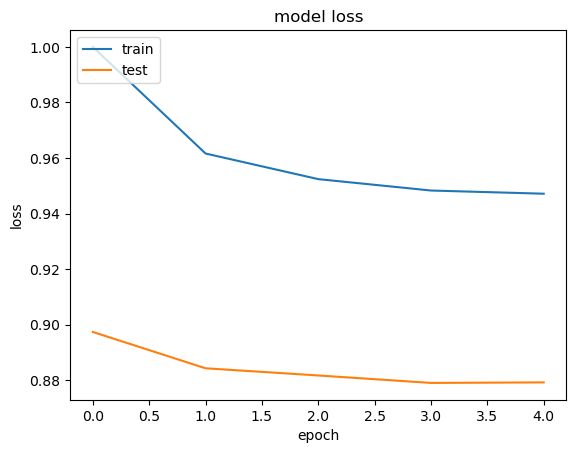

In [65]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()


In [40]:
# save the model
model.save("model_zscore_user.keras")

In [14]:
# load the model
model.load_weights("model_zscore_user.keras")

/home/jakub/anaconda3/envs/keras/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Evaluate the model

In [15]:
test_games_per_user = {}
for i in range(len(test_users)):
    user = test_users[i]
    game = test_games[i]
    if user not in test_games_per_user:
        test_games_per_user[user] = []
    test_games_per_user[user].append(game)

# calculate average
total = 0
for user in test_games_per_user:
    total += len(test_games_per_user[user])
average = total / len(test_games_per_user)
print(f"Average games in the test dataset per user: {average}")

Average games in the test dataset per user: 18.416282642089094


In [16]:
# generate a list of games that are not in the test dataset
train_games_per_user = {}
for i in range(len(train_users)):
    user = train_users[i]
    game = train_games[i]
    if user not in train_games_per_user:
        train_games_per_user[user] = []
    train_games_per_user[user].append(game)

In [17]:
# take game data and map it to the encoded game ids
game_data = pd.read_csv(game_folder)
game_data["game_id"] = game_data["game_id"].map(game2game_encoded)
# remove rows where game_id is nan
game_data = game_data.dropna(subset=['game_id'])
# convert to integer
game_data["game_id"] = game_data["game_id"].astype(int)

In [18]:
len(game_data["game_id"].values)

6113

In [19]:
all_users = np.unique(time_data["user_id"].values)

In [ ]:
recommend_tally = 0
for iter, user_id in tqdm(enumerate(all_users), total=len(all_users)):
    games_played_by_user = time_data[time_data["user_id"] == user_id]["game_id"].values
    try:
        train_games_played_by_user = train_games_per_user[user_id]
    except:
        continue
    try:
        test_games_played_by_user = test_games_per_user[user_id]
    except:
        test_games_played_by_user = []
    # generate a list of games that the user has not played, exclude the test dataset (for evaluation)
    games_not_played_train = list(set(game_data["game_id"].values) - set(train_games_played_by_user))

    user_game_array_train = np.hstack(
        ([[user_id]] * len(games_not_played_train), np.expand_dims(np.array(games_not_played_train), -1))
    )

    playtimes_train = model.predict(user_game_array_train).flatten()

    top_playtime_indices_train = playtimes_train.argsort()[-20:][::-1]

    recommended_game_ids_train = [games_not_played_train[i] for i in top_playtime_indices_train]


    recommended_games_in_test = set(recommended_game_ids_train) & set(test_games_played_by_user)

    recommend_tally += len(recommended_games_in_test)

    if (iter+1)%50 == 0:
        print(recommend_tally / (iter+1))
        print(recommend_tally)

avg = recommend_tally / len(all_users)
print(recommend_tally)
print(avg)

all users: 6580

accurate recommendations: 4308

average: 0.6567

# Generate recommendations for a random user

In [46]:
# get a random user, get the games played by the user
user_id = time_data["user_id"].sample(1).values[0]
games_played_by_user = time_data[time_data["user_id"] == user_id]["game_id"].values

# generate a list of games that the user has not played
games_not_played = list(set(game_data["game_id"].values) - set(games_played_by_user))


In [47]:
user_game_array = np.hstack(
    ([[user_id]] * len(games_not_played), np.expand_dims(np.array(games_not_played), -1))
)


In [48]:
playtimes = model.predict(user_game_array).flatten()

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [49]:
top_playtime_indices = playtimes.argsort()[-10:][::-1]

In [50]:
recommended_game_ids = []
for index in top_playtime_indices:
    game_id = games_not_played[index]
    recommended_game_ids.append(game_id)
    
recommended_game_ids

[4372, 4403, 4367, 4365, 4393, 4106, 4371, 5412, 4081, 4334]

In [53]:
# get 10 most played games by the user
games_played_by_user = time_data[time_data["user_id"] == user_id]
games_played_by_user = games_played_by_user.sort_values(by='playtime', ascending=False)
games_played_by_user = games_played_by_user.head(10)

print("Most played games:")
for row in games_played_by_user.iterrows():
    game_id = row[1]["game_id"]
    game_name = game_data[game_data["game_id"] == game_id]["game_name"].values[0]
    print(game_name, "-", row[1]["playtime"], "hours")


# get the game names
recommended_games = game_data[game_data["game_id"].isin(recommended_game_ids)]

print("\nRecommendations:")
for row in recommended_games.iterrows():
    game_name = row[1]["game_name"]
    print(game_name)

Most played games:
PUBG: BATTLEGROUNDS - 829.0 hours
Apex Legends - 607.0 hours
Grand Theft Auto V - 464.0 hours
Rocket League - 170.0 hours
Fallout 4 - 152.0 hours
Counter-Strike 2 - 115.0 hours
Dying Light - 114.0 hours
State of Decay - 75.0 hours
Among Us - 63.0 hours
Divinity: Original Sin Enhanced Edition - 43.0 hours

Recommendations:
Wild Island Quest
Endless Horde
Shortest Trip to Earth
Last Heroes
Blaster Shooter GunGuy!
Freedom Cry
ANKI
Recursion Deluxe
Epic Quest of the 4 Crystals
An Alien with a Magnet
